In [2]:
# Common Constraints Block
import pyomo.environ as pyo
import os
import cloudpickle as cp

# Default constraints using pyomo
def non_worsening_f1_rule(model, i, N_max, M, epsilon):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.f1[i + 1] <= model.f1[i] + M*(2 - model.y[i] - model.y[i+1]) - epsilon

# Sequential Steps
def sequential_steps_rule(model, i, N_max):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.y[i] >= model.y[i + 1]

def x_fixed_when_y_zero_lower_rule(model, i, j, x_lower, epsilon):
    return model.x[i, j] >= x_lower[j] * model.y[i] + (x_lower[j] + epsilon) * (1 - model.y[i])

def x_fixed_when_y_zero_upper_rule(model, i, j, x_lower, x_upper, epsilon):
    return model.x[i, j] <= x_upper[j] * model.y[i] + (x_lower[j] + epsilon) * (1 - model.y[i])

# Distance Constraints
def distance_constraint_rule(model, i, j, delta, M):
    if i == 0:
        return pyo.Constraint.Skip
    return abs(model.x[i, j] - model.x[i - 1, j]) <= delta[j] + M * (2 - model.y[i] - model.y[i - 1])

# Define z[i] to identify the last active step
def z_definition_rule1(model, i, N_max):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.z[i] <= model.y[i]

def z_definition_rule2(model, i, N_max):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.z[i] <= 1 - model.y[i + 1]

def z_definition_rule3(model, i, N_max):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.z[i] >= model.y[i] - model.y[i + 1]

# Ensure end point is at the last active step
def end_point_constraint(model, i, j, N_max, M, x_end):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.x[i, j] - x_end[j] <= M * (1 - model.z[i])

def end_point_constraint2(model, i, j, N_max, M, x_end):
    if i == N_max:
        return pyo.Constraint.Skip
    return x_end[j] - model.x[i, j] <= M * (1 - model.z[i])

# Normalizing f1
def normalize_f1(model, i, ideal_f1, nadir_f1):
    return (model.f1[i] - ideal_f1) / (nadir_f1 - ideal_f1)  # Added small epsilon to avoid division by zero

def objective_rule(model):
    return sum(
        (model.f1_norm[i] + 1)* model.y[i]
        for i in model.steps
    )


#SCIP implementation, welded beam single objective
# Minimum Steps
# steps constrained on x (non normalized). 
# x_end is minimum f1*
# Problem 1

import numpy as np

# Problem data (as per your updated problem)
n = 4  # Number of variables
N_max_actual = 10
x_start = [2.0, 4.0, 4.0, 2.0]
x_end = [0.24436900072838735, 6.217518384828731, 8.291471787970293, 0.244368953028061]
x_lower = [0.125, 0.1, 0.1, 0.125]
x_upper = [5.0, 10.0, 10.0, 5.0]
delta = [0.1*(x_upper[j] - x_lower[j]) for j in range(n)]
M = 1e6  # Big-M constant
epsilon = 1E-4

N_max = N_max_actual + 1

# Constants for constraints
P = 6000
L = 14
E = 30e6
G = 12e6
tau_max = 13600
sigma_max = 30000


#f_end = 1.10471 * x_end[0]**2 *x_end[1] + 0.04811 * x_end[2] * x_end[3] * (L + x_end[1])

def compute_f1(x):
    return 1.10471 * x[0]**2 * x[1] + 0.04811 * x[2] * x[3] * (L + x[1])

# Compute f1 and f2 at x_start and x_end
f1_start = compute_f1(x_start)
f1_end = compute_f1(x_end)

# Determine ideal and nadir points
ideal_f1 = min(f1_start, f1_end)
nadir_f1 = max(f1_start, f1_end)


# Create Pyomo model
model = pyo.ConcreteModel()

# Sets
model.steps = pyo.RangeSet(0, N_max)
model.dimensions = pyo.RangeSet(0, n - 1)

# Variables
model.x = pyo.Var(model.steps, model.dimensions, within=pyo.Reals, bounds=lambda model, i, j: (x_lower[j], x_upper[j]))
model.y = pyo.Var(model.steps, within=pyo.Binary)
model.z = pyo.Var(model.steps, within=pyo.Binary)  # Auxiliary variable for end point


def compute_f1_expr(model, i):
    x0 = model.x[i, 0]
    x1 = model.x[i, 1]
    x2 = model.x[i, 2]
    x3 = model.x[i, 3]
    return 1.10471 * x0**2 * x1 + 0.04811 * x2 * x3 * (L + x1)

model.f1 = pyo.Expression(model.steps, rule=compute_f1_expr)

# Normalizded f1
model.f1_norm = pyo.Expression(model.steps, rule=lambda model, i: normalize_f1(model, i, ideal_f1, nadir_f1))

## 1) Declare f1_norm as a real variable with the bounds you want:
#model.f1_norm = pyo.Var(model.steps, bounds=(-0.2, 15))

## 2) Replace the old Expression with an equality constraint:
#def f1_norm_def_rule(m, i):
    #return m.f1_norm[i] == (m.f1[i] - ideal_f1)/(nadir_f1 - ideal_f1)
#model.f1_norm_def = pyo.Constraint(model.steps, rule=f1_norm_def_rule)

# Objective Function
model.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)


# Feasibility Constraints
def feasibility_constraint_rule(model, i, k):
    if i == 0:
        return pyo.Constraint.Skip
    x = [model.x[i, j] for j in model.dimensions]
    if k == 1:
        # Shear stress constraint
        R = pyo.sqrt((x[1] ** 2) / 4.0 + ((x[0] + x[2]) ** 2) / 4.0)
        M_val = P * (L + x[1] / 2.0)
        J = 2 * pyo.sqrt(0.5) * x[0] * x[1] * (
            x[1] ** 2 / 12 + 0.25 * (x[0] + x[2]) ** 2
        )
        tau_prime = P / (pyo.sqrt(2) * x[0] * x[1])
        tau_double_prime = M_val * R / J
        tau = pyo.sqrt(
            tau_prime**2
            + tau_double_prime**2
            + tau_prime * tau_double_prime * x[1] / R
        )
        return tau / tau_max - 1 <= M * (1 - model.y[i])
    elif k == 2:
        # Normal stress constraint
        sigma = 6 * P * L / (x[3] * x[2] ** 2)
        return sigma / sigma_max - 1 <= M * (1 - model.y[i])
    elif k == 3:
        # Thickness constraint
        return (x[0] - x[3]) / (5.0 - 0.125) <= M * (1 - model.y[i])
    elif k == 4:
        # Buckling load constraint
        P_c = 64746.022 * (1 - 0.0282346 * x[2]) * x[2] * x[3] ** 3
        return P / P_c - 1 <= M * (1 - model.y[i])
    else:
        return pyo.Constraint.Skip

# Define the feasibility constraints index
model.feasibility_constraints_idx = pyo.RangeSet(1, 4)

model.feasibility_constraints = pyo.Constraint(
    model.steps, model.feasibility_constraints_idx, rule=feasibility_constraint_rule
)

# f1 non worsening constraints
model.non_worsening_f1 = pyo.Constraint(
    model.steps, 
    rule=lambda model, i: non_worsening_f1_rule(model, i, N_max, M, epsilon)
)


# Constraints
# Start Point Fixed
for j in model.dimensions:
    model.x[0, j].fix(x_start[j])
model.y[0].fix(1)  # Start step is active


# Sequential Steps
model.sequential_steps = pyo.Constraint(model.steps, rule= lambda model, i: sequential_steps_rule(model, i, N_max))

# Enforce x[i, j] = x_lower[j] + epsilon when y[i] = 0
model.x_fixed_when_y_zero_lower = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: x_fixed_when_y_zero_lower_rule(model, i, j, x_lower, epsilon))
model.x_fixed_when_y_zero_upper = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: x_fixed_when_y_zero_upper_rule(model, i, j, x_lower, x_upper, epsilon))

# Distance Constraint
model.distance_constraints = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: distance_constraint_rule(model, i, j, delta, M))

# Active Step Identification
model.z_definition1 = pyo.Constraint(model.steps, rule= lambda model, i: z_definition_rule1(model, i, N_max))
model.z_definition2 = pyo.Constraint(model.steps, rule= lambda model, i: z_definition_rule2(model, i, N_max))
model.z_definition3 = pyo.Constraint(model.steps, rule= lambda model, i: z_definition_rule3(model, i, N_max))
# At lease one step has to be active.
model.sum_z = pyo.Constraint(expr=sum(model.z[i] for i in model.steps if i < N_max) == 1)

# Ensure end point is at the last active step
model.end_point_constraint1 = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: end_point_constraint(model, i, j, N_max, M, x_end))
model.end_point_constraint2 = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: end_point_constraint2(model, i, j, N_max, M, x_end))

# Solver Configuration: Using SCIP
solver = pyo.SolverFactory('scip')


# Optional: Set SCIP-specific solver options
solver.options['limits/time'] = 120*60  # Time limit in seconds
solver.options['presolving/maxrounds'] = 5  # Presolving rounds

# Solve the model
result = solver.solve(model, tee=True)

# Check Solver Status
if (result.solver.status == pyo.SolverStatus.ok) and \
   (result.solver.termination_condition == pyo.TerminationCondition.optimal):
    print("Solution is optimal and feasible")
elif result.solver.termination_condition == pyo.TerminationCondition.infeasible:
    print("No feasible solution found")
else:
    print("Solver Status:", result.solver.status)

# Extract and Display the Solution
x_solution = []
for i in model.steps:
    y_i_value = pyo.value(model.y[i])
    if y_i_value > 0.5:
        x_i = np.array([pyo.value(model.x[i, j]) for j in model.dimensions])
        x_solution.append(x_i)

print("\nOptimal sequence of points:")
for idx, x_i in enumerate(x_solution):
    print(f"Step {idx}: x = {x_i}")


# Functionality for Feasibility Verification**

# Compute and Print Objective Function Value
objective_value = pyo.value(model.objective)
print(f"\nObjective Function Value: {objective_value:.6f}")

# Only check constraints for steps where y[i] == 1 (active steps)
active_steps = [i for i in model.steps if pyo.value(model.y[i]) > 0.5]

# Tolerance for floating-point comparison
tol = 1e-8

print("\nFeasibility Check for 'model.feasibility_constraints':")
active_steps = [i for i in model.steps if pyo.value(model.y[i]) > 0.5]

for i in active_steps:
    # skip i=0 because it was explicitly "Skip" in the rule
    if i == 0:
        continue

    for k in model.feasibility_constraints_idx:
        c = model.feasibility_constraints[i, k]
        lhs_val = pyo.value(c.body)
        lb = c.lower
        ub = c.upper

        # Check lower bound
        if lb is not None and lhs_val < lb - 1e-9:
            print(f"feasibility_constraints[{i},{k}]: Violated (lhs={lhs_val} < lb={lb})")
            continue

        # Check upper bound
        if ub is not None and lhs_val > ub + 1e-9:
            print(f"feasibility_constraints[{i},{k}]: Violated (lhs={lhs_val} > ub={ub})")
            continue

        # Otherwise satisfied
        print(f"feasibility_constraints[{i},{k}]: Satisfied (lhs={lhs_val} in [{lb},{ub}])")



# Verify Distance Constraints Between Consecutive Active Steps
print("\nVerification of Distance Constraints Between Consecutive Active Steps:")
active_steps = [i for i in model.steps if pyo.value(model.y[i]) > 0.5]
for idx in range(1, len(active_steps)):
    i_prev = active_steps[idx - 1]
    i_curr = active_steps[idx]
    distance = []
    for j in range(n):
        distance.append(pyo.sqrt((pyo.value(model.x[i_curr, j]) - pyo.value(model.x[i_prev, j]))**2))
    distance_status = "Satisfied" if all(distance[j] <= delta[j] for j in range(n)) else "Violated"
    print(f"Distance between Step {i_prev} and Step {i_curr}:")
    for j in range(n):
        dim_status = "Satisfied" if distance[j] <= delta[j] else "Violated"
        print(f"  Dimension {j}: Distance = {distance[j]:.6f} (delta = {delta[j]}) --> {dim_status}")
    print(f"Overall Status: {distance_status}\n")    

f_values = []
import matplotlib.pyplot as plt

for i in model.steps:
    if pyo.value(model.y[i]) > 0.5:
        f_values.append(pyo.value(compute_f1_expr(model, i)))

# Number of active steps
num_steps = len(f_values)


# --- after solver.solve(model) and status‐checking ---

# After solving and status‐checking…
results_dir = os.path.join(os.getcwd(), "results", "WB_problem")
os.makedirs(results_dir, exist_ok=True)
model_path = os.path.join(results_dir, "WB_model.pkl")

# Save the entire Pyomo model with cloudpickle
with open(model_path, "wb") as f:
    cp.dump(model, f)
print(f"✔ Solved model (with lambdas) saved to {model_path}")



SCIP version 9.2.2 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 7.1.4] [GitHash: 416226a4f8]
Copyright (c) 2002-2025 Zuse Institute Berlin (ZIB)

External libraries: 
  SoPlex 7.1.4         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: 7c53d552]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.3.1           General purpose compression library by J. Gailly and M. Adler (zlib.net)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  ZIMPL 3.6.2          Zuse Institute Mathematical Programming Language developed by T. Koch (zimpl.zib.de)
  AMPL/MP 690e9e7      AMPL .nl file reader library (github.com/ampl/mp)
  PaPILO 2.4.2         parallel presolve for integer and linear optimization (github.com/scipopt/papilo) (built with TBB) [GitHash: 4b399c4c]
  Nauty 2.8.8          Computing Graph Automor

C:\Users\z5368566\AppData\Local\Temp\ipykernel_36932\160166075.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


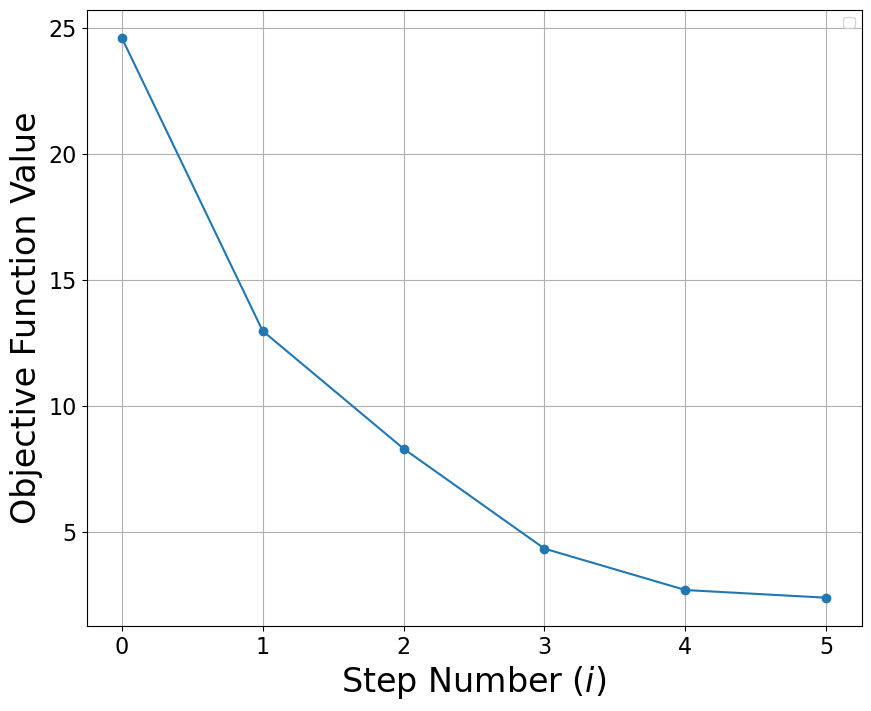

In [3]:
import os
import cloudpickle as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pyomo.environ as pyo

results_dir = os.path.join(os.getcwd(), "results", "WB_problem")
model_path = os.path.join(results_dir, "WB_model.pkl")

# Reload the full model
with open(model_path, "rb") as f:
    loaded_model = cp.load(f)

# Extract just as before
x_solution = []
for i in loaded_model.steps:
    if pyo.value(loaded_model.y[i]) > 0.5:
        x_i = np.array([pyo.value(loaded_model.x[i, j]) 
                        for j in loaded_model.dimensions])
        x_solution.append(x_i)

# Plotting…
fig, ax = plt.subplots(figsize=(10, 8))
# Create a figure and axis
#ax.figure(figsize=(10, 6))
#plt.title('Trajectory of f1 vs f2 Based on Unsorted Steps')
ax.set_xlabel('Step Number ($i$)', fontsize=24)
ax.set_ylabel('Objective Function Value', fontsize=24)

# Plot the points and connect them with lines to show the trajectory
ax.tick_params(axis='both', labelsize=16)
ax.plot(range(len(f_values)), [fv for fv in f_values], marker='o', linestyle='-')
ax.legend()
ax.grid(True)

# Save as PNG & EPS
figures_dir = os.path.join(results_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)
fig.savefig(os.path.join(figures_dir, "WB.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(figures_dir, "WB.eps"), format="eps", bbox_inches="tight")
plt.show()




